In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import factorial
import scipy.linalg as la
import statistics
import pandas as pd

In [128]:
np.random.seed(2408)

In [129]:
# Calculate C from Y using arctan
def C_from_Y(Y):
    #return (np.arctan(Y) + (np.pi / 2)) / np.pi
    return 0.5 * (1 + np.tanh(Y))

# Calculate Y from C using tan
def Y_from_C(C, eps=1e-12):
    C = np.clip(C, eps, 1.0 - eps)
    #return np.tan((np.pi * C) - (np.pi / 2))
    return np.arctanh(2*C - 1)

In [130]:
# Simulate OU on latent Y_t with Euler–Maruyama, then map to C_t in (0,1)
    # dY_t = theta*(nu - Y_t) dt + sigma dW_t
    # C_t  = (1 + tanh(Y_t))/2

def simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N, rng=None):
    
    # nu is the long-term mean of Y_t, approximated by tan transforming mu
    nu = Y_from_C(mu)

    if rng is None:
        rng = np.random.default_rng()

    dt = T / N
    t = np.linspace(0.0, T, N + 1)

    Y = np.empty(N + 1, dtype=float)
    C = np.empty(N + 1, dtype=float)

    Y[0] = Y_from_C(C0)
    C[0] = C0

    for n in range(N):
        eta = rng.standard_normal()
        Y[n + 1] = Y[n] + theta * (nu - Y[n]) * dt + sigma * np.sqrt(dt) * eta   
        C[n + 1] = C_from_Y(Y[n + 1])

    return t, C, Y

In [ ]:
# tau = inf{t >= 0 : C_t <= Ccrit}, estimated from discrete samples
# Returns np.inf if no crossing on [0,T]

def first_passage_time(t, C, Ccrit, use_linear_interp=True):
    
    if C[0] <= Ccrit:
        return t[0]

    for n in range(len(t) - 1):
        if (C[n] > Ccrit) and (C[n + 1] <= Ccrit):
            if not use_linear_interp:
                return t[n + 1]

            # Linear interpolation for a better crossing estimate
            denom = (C[n + 1] - C[n])
            if denom == 0:
                return t[n + 1]
            alpha = (Ccrit - C[n]) / denom
            return t[n] + alpha * (t[n + 1] - t[n])

    return t[len(t) - 1]   # use t[len(t) - 1] to get the expected lifetime plots
    # return np.inf            # use np.inf for the other plots

In [157]:
# Monte Carlo estimates for:
      # - E[tau]
      # - P(tau > T)
      # - optional survival curve S(t) = P(tau > t)

def monte_carlo_lifetime(
    Nr, C0, Ccrit, T, N,
    mu, theta, sigma,
    compute_survival_curve=True,
    rng=None
):
    
    if rng is None:
        rng = np.random.default_rng()

    t_grid = np.linspace(0.0, T, N + 1)
    taus = np.empty(Nr, dtype=float)

    for k in range(Nr):
        t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N, rng=rng)
        taus[k] = first_passage_time(t, C, Ccrit, use_linear_interp=True)

    # Estimates
    finite_taus = taus[np.isfinite(taus)]
    E_tau_hat = np.mean(finite_taus) if len(finite_taus) > 0 else np.inf
    P_survive_T_hat = np.mean(taus > T)   # tau=inf counts as surviving beyond T

    results = {
        "t_grid": t_grid,
        "taus": taus,
        "E_tau_hat": E_tau_hat,
        "P_survive_T_hat": P_survive_T_hat
    }

    if compute_survival_curve:
        S = np.array([np.mean(taus > tt) for tt in t_grid])
        results["survival_curve"] = S

    return results

In [133]:
cmap = plt.get_cmap("viridis") # for plotting

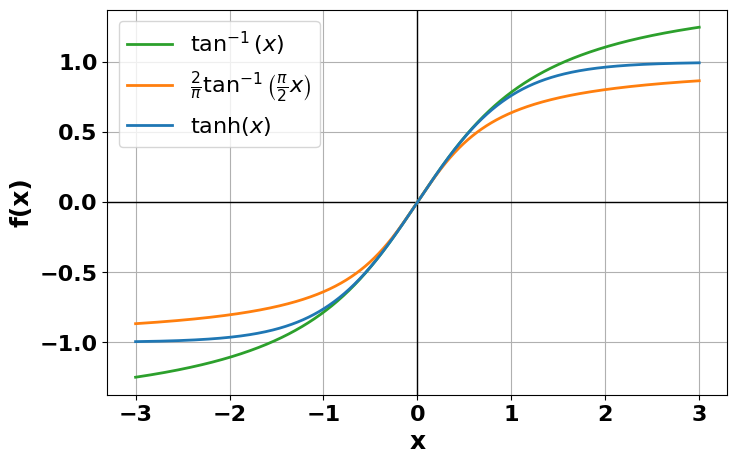

In [134]:

# Comparing Transforms
x = np.linspace(-3, 3, 1000)

f1 = np.arctan(x)                       # tan^{-1}(x)
f2 = (2/np.pi) * np.arctan((np.pi/2)*x) # (2/pi) tan^{-1}((pi/2)x)
f3 = np.tanh(x)                         # tanh(x)

plt.figure(figsize=(8,5))

plt.axhline(0, linewidth=1, color="black")
plt.axvline(0, linewidth=1, color="black")

plt.plot(x, f1, label=r'$\tan^{-1}(x)$', linewidth=2, color="C2")
plt.plot(x, f2, label=r'$\frac{2}{\pi} \tan^{-1}\left(\frac{\pi}{2}x\right)$', linewidth=2, color="C1")
plt.plot(x, f3, label=r'$\tanh(x)$', linewidth=2, color='C0')

plt.xlabel("x", fontsize=18, fontweight='bold')
plt.ylabel("f(x)", fontsize=18, fontweight='bold')
# plt.title("Comparison of Transform Functions")
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.legend(fontsize=16)
plt.grid(True)

plt.savefig("desmos-graph.pdf", bbox_inches='tight')
plt.show()

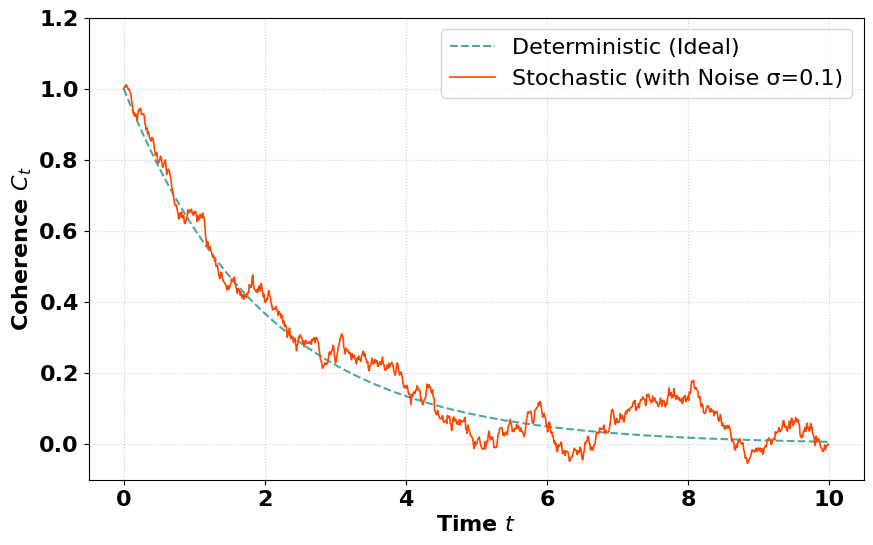

In [168]:
# Coherence Decay: Deterministic vs Noisy Environment

C0 = 1.0        # Initial coherence
theta = 0.5     # Deterministic decay rate
t_max = 10      # Total time
dt = 0.01       # Time step for the simulation
noise_scaled = 0.1  # Strength of the environmental noise

# Time setup
t = np.arange(0, t_max, dt)
n_steps = len(t)

# Deterministic Curve (The baseline)
C_det = C0 * np.exp(-theta * t)

# Stochastic Curve (The noisy version)
# We simulate: dC = -theta * C * dt + sigma * dW
C_stoch = np.zeros(n_steps)
C_stoch[0] = C0

for i in range(1, n_steps):
    # Calculate the random fluctuation (Wiener process increment)
    dW = np.random.normal(0, np.sqrt(dt)) 
    dC = -theta * C_stoch[i-1] * dt + noise_scaled * dW
    C_stoch[i] = C_stoch[i-1] + dC

plt.figure(figsize=(10, 6))

# Plot baseline
plt.plot(t, C_det, label='Deterministic (Ideal)', color='teal', 
         linestyle='--', linewidth=1.5, alpha=0.7)

# Plot noisy version
plt.plot(t, C_stoch, label=f'Stochastic (with Noise σ={noise_scaled})', 
         color='orangered', linewidth=1.2)

# Formatting
# plt.title('Coherence Decay: Deterministic vs. Noisy Environment', fontsize=16)
plt.xlabel('Time $t$', fontsize=16, fontweight='bold')
plt.ylabel('Coherence $C_t$', fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=16)
plt.ylim(-0.1, 1.2) # Noise can occasionally push it slightly below 0

plt.savefig("CoherenceDecay.pdf", bbox_inches='tight')
plt.show()

In [171]:
# Initial Condition and Parameter values
Ccrit = 0.1
C0 = 0.5
mu = 0.5 
theta = 1
sigma = 1
T = 10
N = 1000       # number of EM jumps to take per path
Nr_paths = 5   # number of paths to visualize

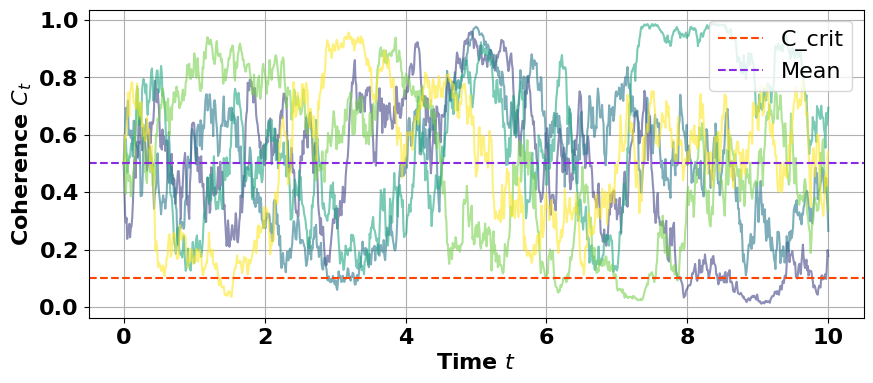

In [138]:
# Coherence Paths (C_t)
plt.figure(figsize=(10,4))

for _ in range(Nr_paths):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    plt.plot(t, C, alpha=0.6, color=cmap((_+1) / Nr_paths))

plt.axhline(Ccrit, color='orangered', linestyle='--', label='C_crit', linewidth=1.5)
plt.axhline(mu, color='blueviolet', linestyle='--', label='Mean', linewidth=1.5)

# plt.title("Qubit Coherence Paths", fontsize=16)
plt.xlabel("Time $t$", fontsize=16, fontweight='bold')
plt.ylabel("Coherence $C_t$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(loc="upper right", bbox_to_anchor=(1, 1), fontsize=16)

plt.savefig("untransformed ct.pdf", bbox_inches='tight')
plt.show()

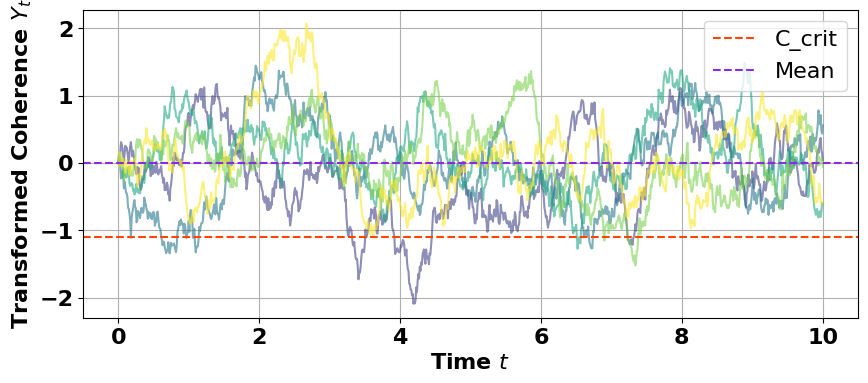

In [143]:
# Transformed Coherence Paths (Y_t)
plt.figure(figsize=(10,4))

for _ in range(Nr_paths):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    plt.plot(t, Y, alpha=0.6, color=cmap((_+1) / Nr_paths))

plt.axhline(Y_from_C(Ccrit), color='orangered', linestyle='--', label='C_crit', linewidth=1.5)
plt.axhline(Y_from_C(mu), color='blueviolet', linestyle='--', label='Mean', linewidth=1.5)

# plt.title("Transformed Qubit Coherence Paths", fontsize=16)
plt.xlabel("Time $t$", fontsize=16, fontweight='bold')
plt.ylabel("Transformed Coherence $Y_t$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(loc="upper right", bbox_to_anchor=(1, 1), fontsize=16)

plt.savefig("transformed yt.pdf", bbox_inches='tight')
plt.show()

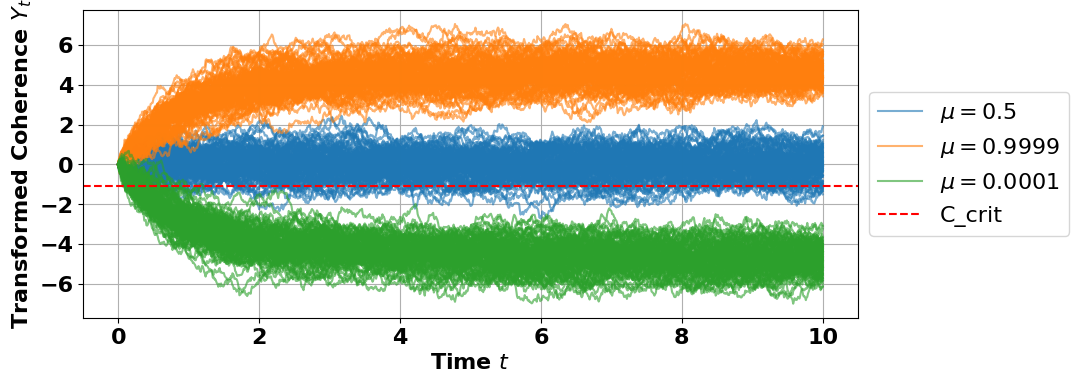

In [172]:
# Transformed Coherence Paths (Y_t)
plt.figure(figsize=(10,4))

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C0', label = '$\\mu = 0.5$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C0')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, 0.9999, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C1', label = '$\\mu = 0.9999$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C1')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, 0.0001, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C2', label = '$\\mu = 0.0001$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C2')

plt.axhline(Y_from_C(Ccrit), color='red', linestyle='--', label='C_crit', linewidth=1.5)

# plt.axhline(Y_from_C(mu), color='red', linestyle='--', label='Mean')
# plt.title("Transformed Qubit Coherence Paths", fontsize=16)
plt.xlabel("Time $t$", fontsize=16, fontweight='bold')
plt.ylabel("Transformed Coherence $Y_t$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=16)

plt.savefig("Yt_different_mu.pdf", bbox_inches='tight')
plt.show()

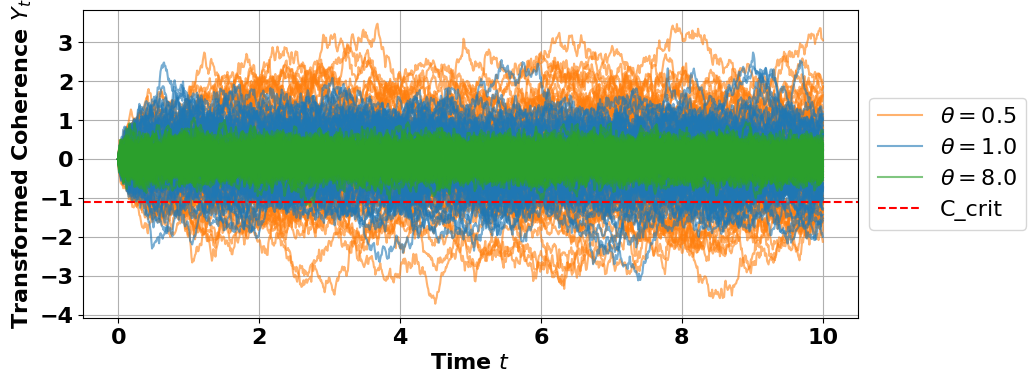

In [147]:
# Transformed Coherence Paths (Y_t)
plt.figure(figsize=(10,4))

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, 0.5, sigma, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C1', label = '$\\theta = 0.5$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C1')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C0', label = '$\\theta = 1.0$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C0')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, 8.0, sigma, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C2', label = '$\\theta = 8.0$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C2')

plt.axhline(Y_from_C(Ccrit), color='red', linestyle='--', label='C_crit', linewidth=1.5)

# plt.axhline(Y_from_C(mu), color='red', linestyle='--', label='Mean')
# plt.title("Transformed Qubit Coherence Paths", fontsize=16)
plt.xlabel("Time $t$", fontsize=16, fontweight='bold')
plt.ylabel("Transformed Coherence $Y_t$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=16)

plt.savefig("Yt_different_theta.pdf", bbox_inches='tight')
plt.show()

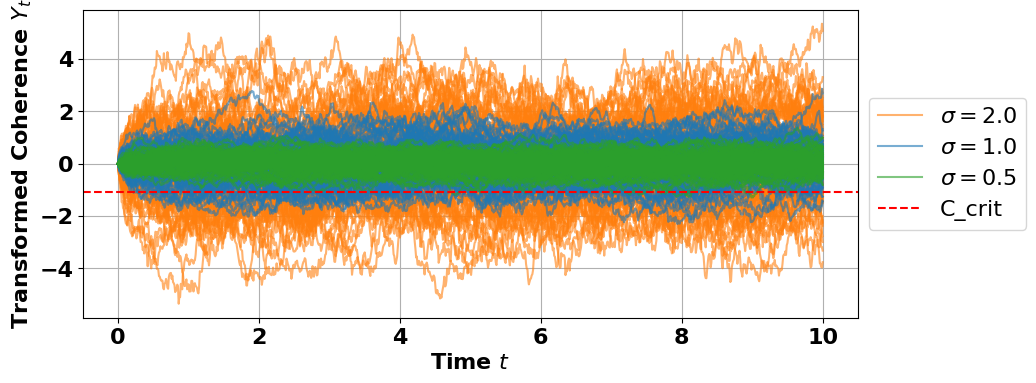

In [148]:
# Transformed Coherence Paths (Y_t)
plt.figure(figsize=(10,4))

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, 2.0, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C1', label = '$\\sigma = 2.0$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C1')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C0', label = '$\\sigma = 1.0$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C0')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, 0.5, T, N)
    if _ == 0:
        plt.plot(t, Y, alpha=0.6, color='C2', label = '$\\sigma = 0.5$')
    else:
        plt.plot(t, Y, alpha=0.6, color='C2')

plt.axhline(Y_from_C(Ccrit), color='red', linestyle='--', label='C_crit', linewidth=1.5)

# plt.axhline(Y_from_C(mu), color='red', linestyle='--', label='Mean')
# plt.title("Transformed Qubit Coherence Paths", fontsize=16)
plt.xlabel("Time $t$", fontsize=16, fontweight='bold')
plt.ylabel("Transformed Coherence $Y_t$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=16)

plt.savefig("Yt_different_sigma.pdf", bbox_inches='tight')
plt.show()

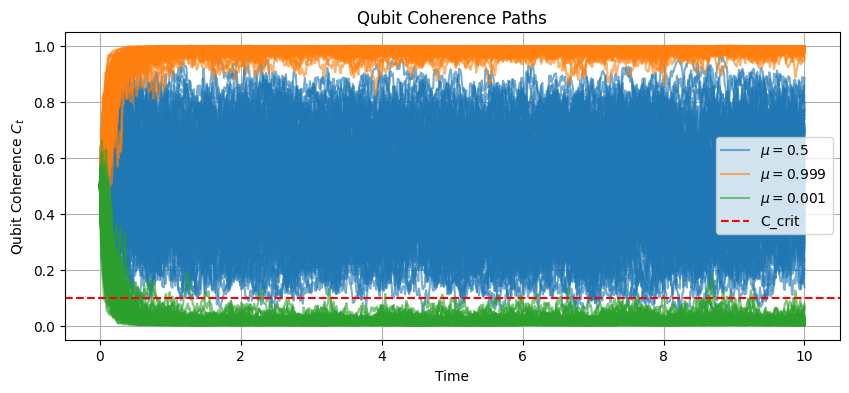

In [141]:
# Coherence Paths (C_t)
plt.figure(figsize=(10,4))

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C0', label = '$\\mu = 0.5$')
    else:
        plt.plot(t, C, alpha=0.6, color='C0')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, 0.99, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C1', label = '$\\mu = 0.999$')
    else:
        plt.plot(t, C, alpha=0.6, color='C1')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, 0.01, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C2', label = '$\\mu = 0.001$')
    else:
        plt.plot(t, C, alpha=0.6, color='C2')

plt.axhline(Ccrit, color='red', linestyle='--', label='C_crit')

# plt.axhline(Y_from_C(mu), color='red', linestyle='--', label='Mean')
plt.title("Qubit Coherence Paths")
plt.xlabel("Time")
plt.ylabel("Qubit Coherence $C_t$")
plt.grid(True)
plt.legend()

plt.show()

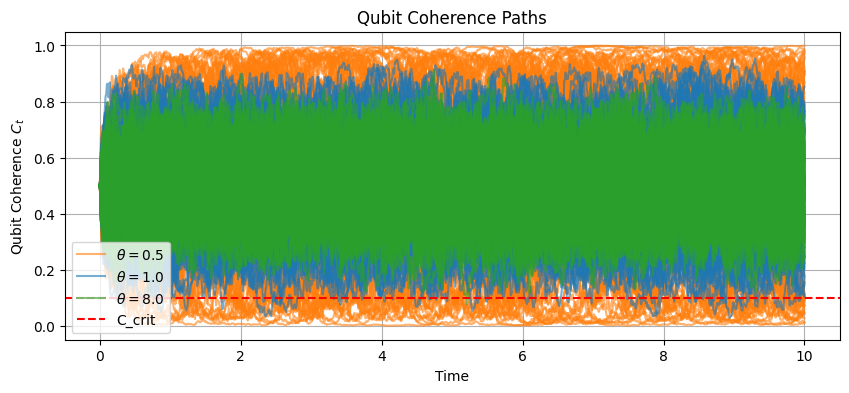

In [142]:
# Coherence Paths (Y_t)
plt.figure(figsize=(10,4))

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, 0.5, sigma, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C1', label = '$\\theta = 0.5$')
    else:
        plt.plot(t, C, alpha=0.6, color='C1')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C0', label = '$\\theta = 1.0$')
    else:
        plt.plot(t, C, alpha=0.6, color='C0')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, 8.0, sigma, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C2', label = '$\\theta = 8.0$')
    else:
        plt.plot(t, C, alpha=0.6, color='C2')

plt.axhline(Ccrit, color='red', linestyle='--', label='C_crit')

# plt.axhline(Y_from_C(mu), color='red', linestyle='--', label='Mean')
plt.title("Qubit Coherence Paths")
plt.xlabel("Time")
plt.ylabel("Qubit Coherence $C_t$")
plt.grid(True)
plt.legend()

plt.show()

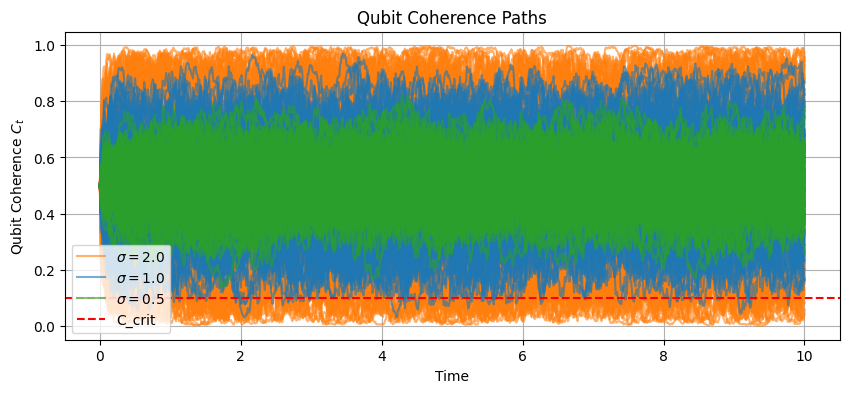

In [143]:
# Coherence Paths (C_t)
plt.figure(figsize=(10,4))

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, 2.0, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C1', label = '$\\sigma = 2.0$')
    else:
        plt.plot(t, C, alpha=0.6, color='C1')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, sigma, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C0', label = '$\\sigma = 1.0$')
    else:
        plt.plot(t, C, alpha=0.6, color='C0')

for _ in range(100):
    t, C, Y = simulate_OU_Y_then_C(C0, mu, theta, 0.5, T, N)
    if _ == 0:
        plt.plot(t, C, alpha=0.6, color='C2', label = '$\\sigma = 0.5$')
    else:
        plt.plot(t, C, alpha=0.6, color='C2')

plt.axhline(Ccrit, color='red', linestyle='--', label='C_crit')

# plt.axhline(Y_from_C(mu), color='red', linestyle='--', label='Mean')
plt.title("Qubit Coherence Paths")
plt.xlabel("Time")
plt.ylabel("Qubit Coherence $C_t$")
plt.grid(True)
plt.legend()

plt.show()

In [149]:
# Monte Carlo Simulations for tau histogram and survivability curve
results = monte_carlo_lifetime(
    Nr=100000,
    C0=C0,
    Ccrit=Ccrit,
    T=T,
    N=N,
    mu=mu,
    theta=theta,
    sigma=sigma
)

# For histogram of first time passages
taus = results["taus"]
finite_taus = taus[np.isfinite(taus)]

# For survivability probability curve
t_grid = results["t_grid"]
S = results["survival_curve"]

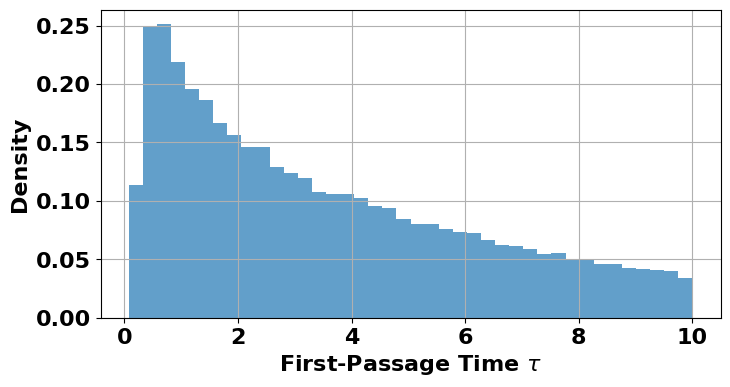

In [150]:
# Histogram for first time passages
plt.figure(figsize=(8,4))

plt.hist(finite_taus, bins=40, density=True, alpha=0.7)

# plt.title("Distribution of First-Passage Times")
plt.xlabel("First-Passage Time $\\tau$", fontsize=16, fontweight='bold')
plt.ylabel("Density", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)

plt.savefig("First_Passage_Histogram.pdf", bbox_inches='tight')
plt.show()

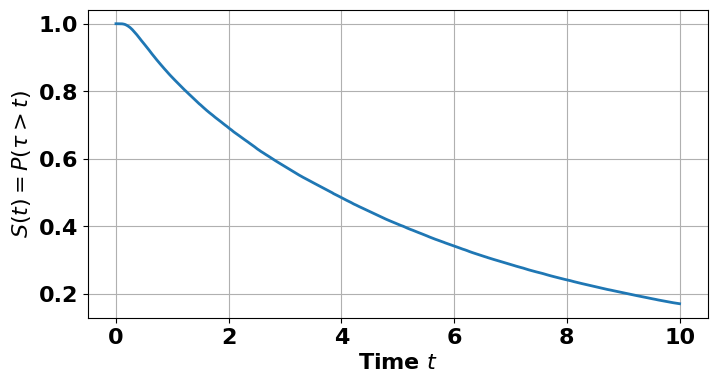

In [151]:
# Survival Probability Curve
plt.figure(figsize=(8,4))

plt.plot(t_grid, S, linewidth=2)

# plt.title("Survival Probability of Qubit Coherence")
plt.xlabel("Time $t$", fontsize=16, fontweight='bold')
plt.ylabel("$S(t) = P(\\tau > t)$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)

plt.savefig("Survival_Prob_Curve.pdf", bbox_inches='tight')
plt.show()

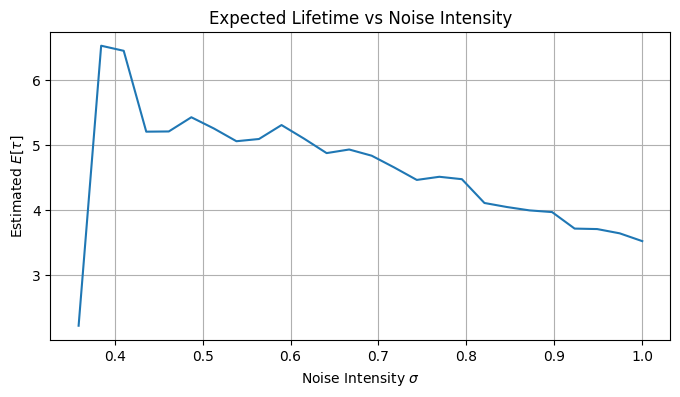

In [ ]:
# Effect of Noise Intensity (different sigmas)
sigma_vals = np.linspace(0,1,40)
E_tau_vals = []

for s in sigma_vals:
    res = monte_carlo_lifetime(
        Nr=2000,
        C0=C0,
        Ccrit=Ccrit,
        T=T,
        N=N,
        mu=mu,
        theta=theta,
        sigma=s
    )
    E_tau_vals.append(res["E_tau_hat"])

plt.figure(figsize=(8,4))

plt.plot(sigma_vals, E_tau_vals)

plt.title("Expected Lifetime vs Noise Intensity")
plt.xlabel("Noise Intensity $\\sigma$")
plt.ylabel("Estimated $E[\\tau]$")
plt.grid(True)

plt.show()

In [159]:
# Monte Carlo Simulations for Contour Maps
theta_vals = np.linspace(0, 3.0, 20)
sigma_vals = np.linspace(0, 1.0, 20)

E_tau_grid = np.zeros((len(theta_vals), len(sigma_vals)))
Survival_grid = np.zeros((len(theta_vals), len(sigma_vals)))

for i, theta in enumerate(theta_vals):
    for j, sigma in enumerate(sigma_vals):

        res = monte_carlo_lifetime(
            Nr=2000,
            C0=C0,
            Ccrit=Ccrit,
            T=T,
            N=N,
            theta=theta,
            sigma=sigma,
            mu=mu
        )

        E_tau_grid[i,j] = res["E_tau_hat"]
        Survival_grid[i,j] = res["P_survive_T_hat"]

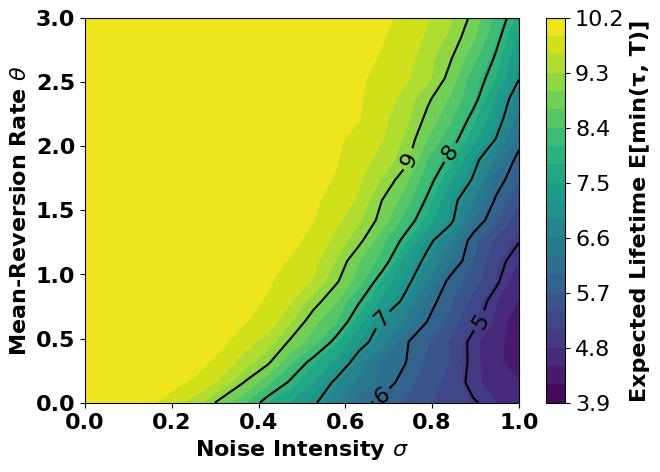

In [160]:
# Contour plot for Expected Lifetime
plt.figure(figsize=(7,5))

CS = plt.contourf(
    sigma_vals,
    theta_vals,
    E_tau_grid,
    levels=20
)

CS1 = plt.contour(
    sigma_vals,
    theta_vals,
    E_tau_grid,
    levels=[5.0,6.0,7.0,8.0,9.0],
    colors="black",
    linewidths=1.5
)

plt.clabel(CS1, fontsize=16)

# plt.colorbar(CS, label="Expected Lifetime E[τ]", fontsize=20)
cbar = plt.colorbar(CS)
cbar.set_label("Expected Lifetime E[min(τ, T)]", fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=16)

plt.xlabel("Noise Intensity $\\sigma$", fontsize=16, fontweight='bold')
plt.ylabel("Mean-Reversion Rate $\\theta$", fontsize=16, fontweight='bold')
# plt.title("Expected Lifetime Contour Plot", fontsize=20)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

plt.savefig("Expected_Lifetime_Contour.pdf", bbox_inches='tight')
plt.show()

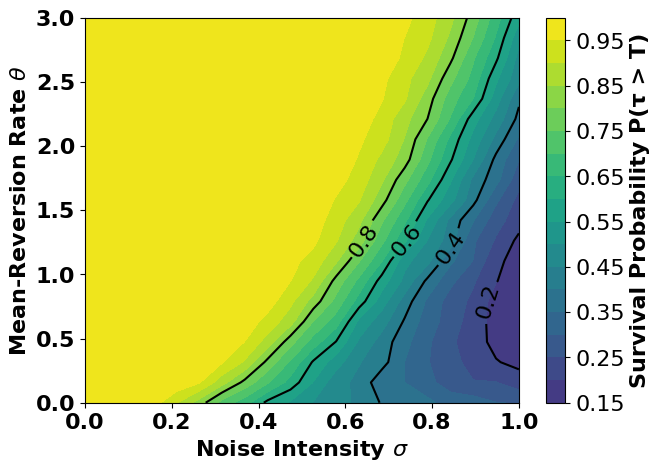

In [155]:
# Contour plot for Survival Probability
plt.figure(figsize=(7,5))

CS = plt.contourf(
    sigma_vals,
    theta_vals,
    Survival_grid,
    levels=20,
    vmin=0, vmax=1
)

CS1 = plt.contour(
    sigma_vals,
    theta_vals,
    Survival_grid,
    levels=[0.2,0.4,0.6,0.8],
    colors="black",
    linewidths=1.5
)

plt.clabel(CS1, fontsize=16)

# plt.colorbar(CS, label="P(τ > T)", fontsize=20)
cbar = plt.colorbar(CS)
cbar.set_label("Survival Probability P(τ > T)", fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=16)

plt.xlabel("Noise Intensity $\\sigma$", fontsize=16, fontweight='bold')
plt.ylabel("Mean-Reversion Rate $\\theta$", fontsize=16, fontweight='bold')
# plt.title("Survival Probability Contour Plot", fontsize=20)
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

plt.savefig("Survival_Prob_Contour.pdf", bbox_inches='tight')
plt.show()

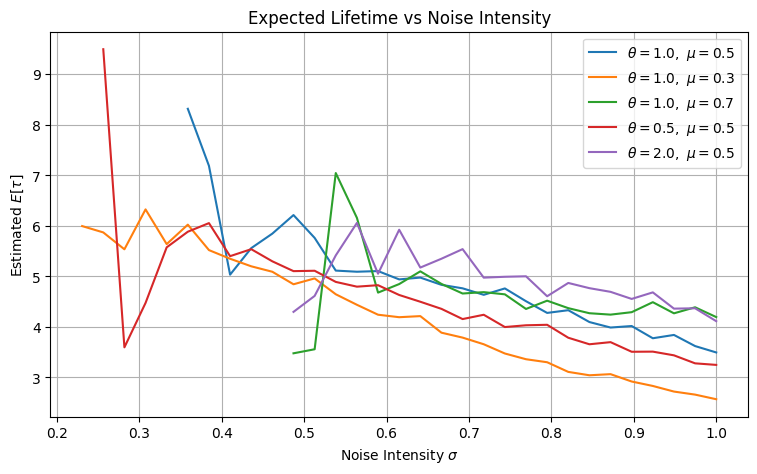

In [ ]:
# Expected Lifetime vs Noise Intensity for different thetas and sigmas
sigma_vals = np.linspace(0, 1, 40)

parameter_sets = [
    {"theta": 1.0, "mu": 0.5, "label": r"$\theta=1.0,\ \mu=0.5$"},
    {"theta": 1.0, "mu": 0.3, "label": r"$\theta=1.0,\ \mu=0.3$"},
    {"theta": 1.0, "mu": 0.7, "label": r"$\theta=1.0,\ \mu=0.7$"},
    {"theta": 0.5, "mu": 0.5, "label": r"$\theta=0.5,\ \mu=0.5$"},
    {"theta": 2.0, "mu": 0.5, "label": r"$\theta=2.0,\ \mu=0.5$"},
]

plt.figure(figsize=(9,5))

for params in parameter_sets:
    E_tau_vals = []

    for s in sigma_vals:
        res = monte_carlo_lifetime(
            Nr=2000,
            C0=C0,
            Ccrit=Ccrit,
            T=T,
            N=N,
            mu=params["mu"],
            theta=params["theta"],
            sigma=s
        )
        E_tau_vals.append(res["E_tau_hat"])

    plt.plot(sigma_vals, E_tau_vals, label=params["label"])

plt.title("Expected Lifetime vs Noise Intensity")
plt.xlabel(r"Noise Intensity $\sigma$")
plt.ylabel(r"Estimated $E[\tau]$")
plt.grid(True)
plt.legend()
plt.show()

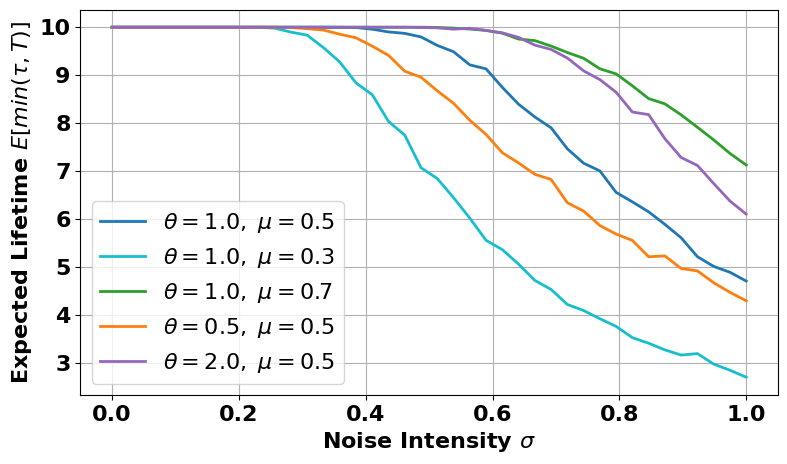

In [170]:
# Expected Lifetime vs Noise Intensity for different thetas and sigmas
sigma_vals = np.linspace(0, 1, 40)

parameter_sets = [
    {"theta": 1.0, "mu": 0.5, "label": r"$\theta=1.0,\ \mu=0.5$"},
    {"theta": 1.0, "mu": 0.3, "label": r"$\theta=1.0,\ \mu=0.3$"},
    {"theta": 1.0, "mu": 0.7, "label": r"$\theta=1.0,\ \mu=0.7$"},
    {"theta": 0.5, "mu": 0.5, "label": r"$\theta=0.5,\ \mu=0.5$"},
    {"theta": 2.0, "mu": 0.5, "label": r"$\theta=2.0,\ \mu=0.5$"},
]

plt.figure(figsize=(9,5))

n = 0
clr = ['C0', 'C9', 'C2', 'C1', 'C4']

for params in parameter_sets:
    E_tau_vals = []

    for s in sigma_vals:
        res = monte_carlo_lifetime(
            Nr=2000,
            C0=C0,
            Ccrit=Ccrit,
            T=T,
            N=N,
            mu=params["mu"],
            theta=params["theta"],
            sigma=s
        )
        E_tau_vals.append(res["E_tau_hat"])

    plt.plot(sigma_vals, E_tau_vals, label=params["label"], linewidth=2, color=clr[n])
    n+=1

# plt.title("Expected Lifetime vs Noise Intensity")
plt.xlabel(r"Noise Intensity $\sigma$", fontsize=16, fontweight='bold')
plt.ylabel(r"Expected Lifetime $E[min(\tau,T)]$", fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.grid(True)
plt.legend(fontsize=16)

plt.savefig("E(tau)_vs_sigma_smoother.pdf", bbox_inches='tight')
plt.show()